# PyTorch dataset testing for specific project

In [1]:
# Must be set BEFORE torch is imported: cuBLAS reads this once, when it initializes, so
# setting it later has no effect. It is what lets training.deterministic work without a
# cuBLAS warning on every run. (Restart the kernel if torch was already imported.)
import os
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

import numpy as np
import sys
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import sunpy.visualization.colormaps as cm
import matplotlib.gridspec as gridspec

import yaml

# Append base path.  May need to be modified if the folder structure changes.
# It gives the notebook access to the wokshop_infrastructure folder.
sys.path.append("../../")
 
# Append Surya path. May need to be modified if the folder structure changes.
# It gives the notebook access to surya's release code.

from workshop_infrastructure.utils import build_scalers  # Data scaling utilities for Surya stacks

## Load configuration


In [2]:
# The config is the single source of truth. load_flare_config() parses it into a typed
# object, exactly as the training script 3_finetune_template_1D.py does, so the same YAML
# behaves identically in the notebook and in production.
#
# Typed means: cfg.data.channels instead of config["data"]["channels"] — you get IDE
# completion, and a misspelled key fails here with a list of the valid ones instead of
# silently doing nothing.
from downstream_apps.template.configs import load_flare_config

cfg = load_flare_config("./configs/config_script.yaml")
print(f"Loaded config for job: {cfg.job_id}")

# Paths in the YAML are relative to the config file, and come back resolved:
print(f"  train index : {cfg.data.train_data_path}")
print(f"  scalers     : {cfg.data.scalers_path}")


Loaded config for job: solar_flare_forecasting
  train index : /home/jovyan/tmp/surya_workshop/data/indices/surya_aws_s3_train.csv
  scalers     : /home/jovyan/tmp/surya_workshop/downstream_apps/flare_forecast/assets/scalers.yaml


## Download assets



In [3]:
# One implementation, shared by the notebooks, the training script and the
# download_*.sh wrappers: workshop_infrastructure/assets.py.
# This notebook only needs the scalers - no backbone is loaded.
from workshop_infrastructure.assets import ensure_assets

ensure_assets(cfg, which=["scalers"])

# Now that scalers.yaml is guaranteed to be on disk, load it. build_scalers()
# accepts the resolved path directly.
scalers = build_scalers(info=cfg.data.scalers_path)
print(f"Loaded scalers for {len(scalers)} channels.")


Loaded scalers for 13 channels.


## Define DS dataset

In [4]:
from downstream_apps.flare_forecast.datasets.flare_dataset import flare_Dataset

## dataset class - uses probability 50% of flipping

### trying to get image intervals less than 1 hour 
#### note: its in 12 min intervals and changed in config yaml script

In [5]:
cfg = load_flare_config("./configs/config_script.yaml")

train_dataset = flare_Dataset(
    #### All these lines are required by the parent HelioNetCDFDataset class
    index_path=cfg.data.train_data_path,
    time_delta_input_minutes=cfg.data.time_delta_input_minutes,
    time_delta_target_minutes=cfg.data.time_delta_target_minutes,
    n_input_timestamps=cfg.model.time_embedding.time_dim,
    rollout_steps=cfg.rollout_steps,
    channels=cfg.data.channels,
    drop_hmi_probability=cfg.drop_hmi_probability,
    use_latitude_in_learned_flow=cfg.use_latitude_in_learned_flow,
    scalers=scalers,
    phase="train",          # "val" disables random channel masking and flips
    # How s3:// paths in the index are read: "download" (default) | "simplecache" | "stream".
    # "download" fetches each file into s3_cache_dir first — recommended for NetCDF.
    s3_mode=cfg.data.s3_mode,
    s3_storage_options={"anon": cfg.data.s3_anon},
    s3_cache_dir=cfg.data.s3_cache_dir,
    #### Put your downstream (DS) specific parameters below this line
    return_surya_stack=True,
    max_number_of_samples=None,   # <- was 6, no cap so we can see the X-class events
    ds_flare_index_path=cfg.data.flare_index_path,
    ds_time_column=cfg.data.ds_time_column,
    ds_time_tolerance=cfg.data.ds_time_tolerance,
    ds_match_direction=cfg.data.ds_match_direction,
    flip_probability=0.5, #THIS HERE IS ODDS IT'LL FLIP OR NOT
)

# Notebooks 1 and 2 skip this block entirely: build_helio_dataloaders() in
# workshop_infrastructure/datasets/builders.py fills in everything above the
# "downstream specific" line straight from the config.

In [6]:
#item = train_dataset.__getitem__(0)

## looking for x-class flares for visual inspection

In [7]:
import numpy as np

x_class_mask = train_dataset.df_valid_indices['GOES_class'].str.startswith('X')
positions = np.where(x_class_mask.values)[0]
print(f"found {len(positions)} X-class matches")
print(train_dataset.df_valid_indices.iloc[positions][
    ['GOES_class', 'start_time', 'peak_time', 'end_time', 'ds_index']
])

found 39 X-class matches
                    GOES_class           start_time            peak_time  \
valid_indices                                                              
2011-03-09 23:12:00       X1.5  2011-03-09T23:13:00  2011-03-09T23:23:00   
2011-08-09 08:00:00       X6.9  2011-08-09T07:48:00  2011-08-09T08:05:00   
2011-09-06 22:12:00       X2.1  2011-09-06T22:12:00  2011-09-06T22:20:00   
2011-09-07 22:36:00       X1.8  2011-09-07T22:32:00  2011-09-07T22:38:00   
2011-09-24 09:12:00       X1.9  2011-09-24T09:21:00  2011-09-24T09:40:00   
2011-11-03 20:24:00       X1.9  2011-11-03T20:16:00  2011-11-03T20:27:00   
2013-05-13 02:12:00       X1.7  2013-05-13T01:53:00  2013-05-13T02:17:00   
2013-05-13 16:00:00       X2.8  2013-05-13T15:48:00  2013-05-13T16:05:00   
2013-05-14 01:00:00       X3.2  2013-05-14T00:00:00  2013-05-14T01:11:00   
2013-05-15 01:48:00       X1.2  2013-05-15T01:25:00  2013-05-15T01:48:00   
2013-10-25 08:00:00       X1.7  2013-10-25T07:53:00  2013-10-25

In [8]:
idx = positions[34]   # or pick a specific row from the printout above
item = train_dataset.__getitem__(idx)
print(train_dataset.df_valid_indices.iloc[idx][
    ['GOES_class', 'start_time', 'peak_time', 'end_time', 'ds_index']
])

GOES_class                   X9.3
start_time    2017-09-06T11:53:00
peak_time     2017-09-06T12:02:00
end_time      2017-09-06T12:10:00
ds_index      2017-09-06 12:02:00
Name: 2017-09-06 12:00:00, dtype: object


In [9]:
import pandas as pd

flare_catalog = pd.read_csv(cfg.data.flare_index_path)
flare_catalog['start_time'] = pd.to_datetime(flare_catalog['start_time'])
flare_catalog['end_time'] = pd.to_datetime(flare_catalog['end_time'])

event_time = pd.Timestamp(item['ds_index'])

match = flare_catalog[
    (flare_catalog['start_time'] <= event_time) &
    (flare_catalog['end_time'] >= event_time)
]

if not match.empty:
    print(f"Flare in progress at {event_time}:")
    print(match[['start_time', 'peak_time', 'end_time', 'GOES_class']])
else:
    print(f"No flare in progress at {event_time} (nearest events below):")
    nearest = flare_catalog.iloc[(flare_catalog['start_time'] - event_time).abs().argsort()[:3]]
    print(nearest[['start_time', 'peak_time', 'end_time', 'GOES_class']])

Flare in progress at 2017-09-06 12:02:00:
               start_time            peak_time            end_time GOES_class
57756 2017-09-06 11:53:00  2017-09-06T12:02:00 2017-09-06 12:10:00       X9.3


Input timestamps: [Timestamp('2017-09-06 11:02:00'), Timestamp('2017-09-06 11:26:00')]
WILL FORECAST timestamp: [Timestamp('2017-09-06 12:02:00')]


[input]  t=0 timestamp=2017-09-06 11:02:00 min=0.0000 max=1963.1012 mean=1.2188


[input]  t=1 timestamp=2017-09-06 11:26:00 min=0.0000 max=1712.8401 mean=1.2150


[ground_truth] l=0 timestamp=2017-09-06 12:02:00 min=0.0000 max=16383.0010 mean=4.0832


/tmp/ipykernel_2067/2071090896.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


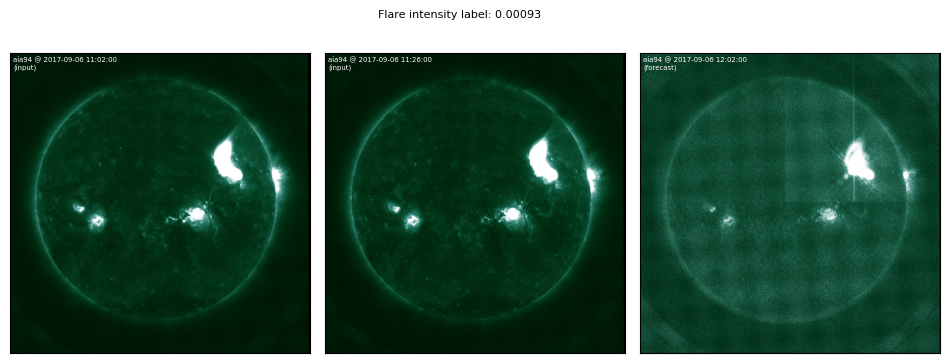

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

anchor_time = pd.Timestamp(item['ds_index'])
input_offsets = cfg.data.time_delta_input_minutes
frame_timestamps = [anchor_time + pd.Timedelta(minutes=off) for off in input_offsets]
print("Input timestamps:", frame_timestamps)

target_offsets = cfg.data.time_delta_target_minutes
n_lead_steps = item['forecast'].shape[1]
target_timestamps = [anchor_time + pd.Timedelta(minutes=target_offsets * (l + 1)) for l in range(n_lead_steps)]
print("WILL FORECAST timestamp:", target_timestamps)

n = 0
channel_order = cfg.data.channels
channel = channel_order[n]
n_timesteps = item['ts'].shape[1]

n_cols = n_timesteps + n_lead_steps
fig = plt.figure(figsize=np.array([4 * n_cols, 4]), dpi=100)
gs = gridspec.GridSpec(1, n_cols, figure=fig, wspace=0.05, hspace=0)

def plot_frame(ax, plot_ts, label):
    if 'hmi' not in channel:
        lim = np.percentile(plot_ts[plot_ts != 0], 99)
        ax.imshow(plot_ts, cmap=f'sdo{channel}', vmin=0, vmax=lim)
        font_color = 'w'
    else:
        font_color = 'k'
        lim = 1000
        if "_v" not in channel:
            ax.imshow(plot_ts, cmap='hmimag', vmin=-lim, vmax=lim)
        else:
            ax.imshow(plot_ts, cmap='coolwarm', vmin=-lim, vmax=lim)
    ax.text(0.01, 0.99, label, transform=ax.transAxes,
            horizontalalignment='left', verticalalignment='top',
            color=font_color, fontsize=5)
    ax.set_xticks([])
    ax.set_yticks([])

for t in range(n_timesteps):
    ts_frame = train_dataset.inverse_transform_data(item['ts'][:, t, ...])
    plot_ts = ts_frame[n, ...]
    print(f"[input]  t={t} timestamp={frame_timestamps[t]} min={plot_ts.min():.4f} max={plot_ts.max():.4f} mean={plot_ts.mean():.4f}")
    ax = fig.add_subplot(gs[0, t])
    plot_frame(ax, plot_ts, f"{channel} @ {frame_timestamps[t]}\n(input)")

for l in range(n_lead_steps):
    forecast_frame = train_dataset.inverse_transform_data(item['forecast'][:, l, ...])
    plot_ts = forecast_frame[n, ...]
    print(f"[ground_truth] l={l} timestamp={target_timestamps[l]} min={plot_ts.min():.4f} max={plot_ts.max():.4f} mean={plot_ts.mean():.4f}")
    ax = fig.add_subplot(gs[0, n_timesteps + l])
    plot_frame(ax, plot_ts, f"{channel} @ {target_timestamps[l]}\n(forecast)")

fig.suptitle(f"Flare intensity label: {float(item['ground_truth']):.4g}", fontsize=8)
plt.tight_layout()
plt.show()

In [11]:
print("input t0 vs input t1 identical?", np.array_equal(item['ts'][:, 0], item['ts'][:, 1]))
print("input t1 vs forecast identical?", np.array_equal(item['ts'][:, 1], item['forecast'][:, 0]))

input t0 vs input t1 identical? False
input t1 vs forecast identical? False


In [12]:
reference_timestep = train_dataset.valid_indices[idx]
print("reference_timestep (actually used to load frames):", reference_timestep)
print("ds_index (flare catalog label, may differ):", item['ds_index'])

input_offsets = cfg.data.time_delta_input_minutes          # [-120, -60]
target_offset = cfg.data.time_delta_target_minutes          # 0

true_timesteps = [reference_timestep + pd.Timedelta(minutes=m) for m in input_offsets]
true_timesteps.append(reference_timestep + pd.Timedelta(minutes=target_offset))

for ts in true_timesteps:
    print(ts, "->", train_dataset.index.loc[ts, "path"])

reference_timestep (actually used to load frames): 2017-09-06 12:00:00
ds_index (flare catalog label, may differ): 2017-09-06T12:02:00
2017-09-06 11:00:00 -> s3://nasa-surya-bench/2017/09/20170906_1100.nc
2017-09-06 11:24:00 -> s3://nasa-surya-bench/2017/09/20170906_1124.nc
2017-09-06 12:00:00 -> s3://nasa-surya-bench/2017/09/20170906_1200.nc


#### still hard to see -- running difference image to check 

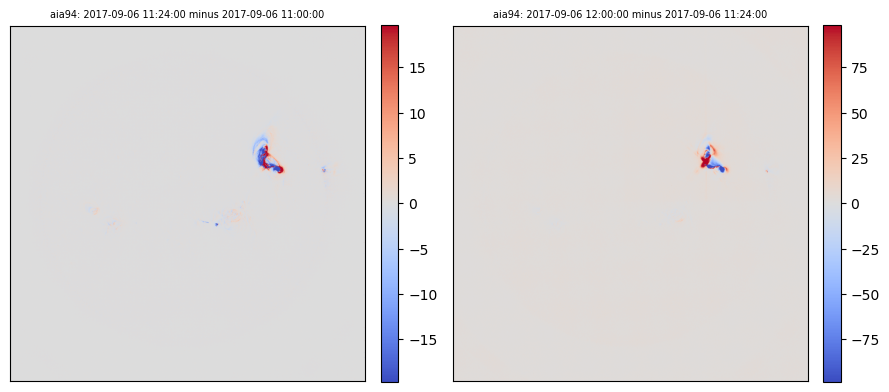

In [13]:
import numpy as np
import matplotlib.pyplot as plt

n = 0  # channel index — matches the channel used in the earlier plotting cell
channel = cfg.data.channels[n]

# Use the true reference timestep (not ds_index) for accurate labels
reference_timestep = train_dataset.valid_indices[idx]
input_offsets = cfg.data.time_delta_input_minutes
target_offset = cfg.data.time_delta_target_minutes
t0_time = reference_timestep + pd.Timedelta(minutes=input_offsets[0])
t1_time = reference_timestep + pd.Timedelta(minutes=input_offsets[1])
fc_time = reference_timestep + pd.Timedelta(minutes=target_offset)

frame_t0 = train_dataset.inverse_transform_data(item['ts'][:, 0, ...])[n]
frame_t1 = train_dataset.inverse_transform_data(item['ts'][:, 1, ...])[n]
frame_fc = train_dataset.inverse_transform_data(item['forecast'][:, 0, ...])[n]

diff_inputs = frame_t1 - frame_t0        # t1 - t0
diff_forecast = frame_fc - frame_t1      # forecast - t1

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5), dpi=100)

for ax, diff, title in zip(
    axes,
    [diff_inputs, diff_forecast],
    [f"{channel}: {t1_time} minus {t0_time}",
     f"{channel}: {fc_time} minus {t1_time}"],
):
    lim = np.percentile(np.abs(diff), 99)*10
    im = ax.imshow(diff, cmap='coolwarm', vmin=-lim, vmax=lim)
    ax.set_title(title, fontsize=7)
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

Input timestamps: [Timestamp('2017-09-06 11:02:00'), Timestamp('2017-09-06 11:26:00')]
WILL FORECAST timestamp: [Timestamp('2017-09-06 12:02:00')]


[input]  t=0 timestamp=2017-09-06 11:02:00 min=0.0000 max=1963.1012 mean=1.2188


[input]  t=1 timestamp=2017-09-06 11:26:00 min=0.0000 max=1712.8401 mean=1.2150


[ground_truth] l=0 timestamp=2017-09-06 12:02:00 min=0.0000 max=16383.0010 mean=4.0832


/tmp/ipykernel_2067/3832773984.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


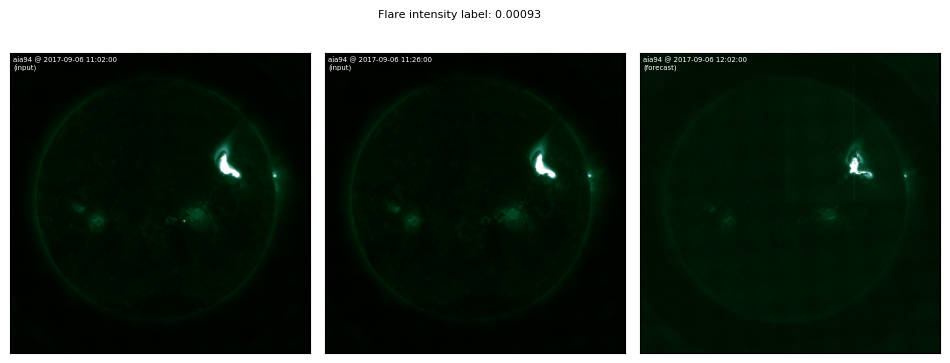

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

anchor_time = pd.Timestamp(item['ds_index'])
input_offsets = cfg.data.time_delta_input_minutes
frame_timestamps = [anchor_time + pd.Timedelta(minutes=off) for off in input_offsets]
print("Input timestamps:", frame_timestamps)

target_offsets = cfg.data.time_delta_target_minutes
n_lead_steps = item['forecast'].shape[1]
target_timestamps = [anchor_time + pd.Timedelta(minutes=target_offsets * (l + 1)) for l in range(n_lead_steps)]
print("WILL FORECAST timestamp:", target_timestamps)

n = 0
channel_order = cfg.data.channels
channel = channel_order[n]
n_timesteps = item['ts'].shape[1]

n_cols = n_timesteps + n_lead_steps
fig = plt.figure(figsize=np.array([4 * n_cols, 4]), dpi=100)
gs = gridspec.GridSpec(1, n_cols, figure=fig, wspace=0.05, hspace=0)

def plot_frame(ax, plot_ts, label):
    if 'hmi' not in channel:
        lim = np.percentile(plot_ts[plot_ts != 0], 99)*10
        ax.imshow(plot_ts, cmap=f'sdo{channel}', vmin=0, vmax=lim)
        font_color = 'w'
    else:
        font_color = 'k'
        lim = np.percentile(plot_ts[plot_ts != 0], 99)*10
        if "_v" not in channel:
            ax.imshow(plot_ts, cmap='hmimag', vmin=-lim, vmax=lim)
        else:
            ax.imshow(plot_ts, cmap='coolwarm', vmin=-lim, vmax=lim)
    ax.text(0.01, 0.99, label, transform=ax.transAxes,
            horizontalalignment='left', verticalalignment='top',
            color=font_color, fontsize=5)
    ax.set_xticks([])
    ax.set_yticks([])

for t in range(n_timesteps):
    ts_frame = train_dataset.inverse_transform_data(item['ts'][:, t, ...])
    plot_ts = ts_frame[n, ...]
    print(f"[input]  t={t} timestamp={frame_timestamps[t]} min={plot_ts.min():.4f} max={plot_ts.max():.4f} mean={plot_ts.mean():.4f}")
    ax = fig.add_subplot(gs[0, t])
    plot_frame(ax, plot_ts, f"{channel} @ {frame_timestamps[t]}\n(input)")

for l in range(n_lead_steps):
    forecast_frame = train_dataset.inverse_transform_data(item['forecast'][:, l, ...])
    plot_ts = forecast_frame[n, ...]
    print(f"[ground_truth] l={l} timestamp={target_timestamps[l]} min={plot_ts.min():.4f} max={plot_ts.max():.4f} mean={plot_ts.mean():.4f}")
    ax = fig.add_subplot(gs[0, n_timesteps + l])
    plot_frame(ax, plot_ts, f"{channel} @ {target_timestamps[l]}\n(forecast)")

fig.suptitle(f"Flare intensity label: {float(item['ground_truth']):.4g}", fontsize=8)
plt.tight_layout()
plt.show()

FLARE EVENT      : X9.3   
  start_time     : 2017-09-06T11:53:00
  peak_time      : 2017-09-06T12:02:00
  end_time       : 2017-09-06T12:10:00
 
 
ds_time_column = 'peak_time'  ->  2017-09-06 12:02:00
 
Ground Truth 2017-09-06 12:00:00
Reference Timestamp (helio.py anchor): 2017-09-06 12:00:00
    offset from peak_time  : 0 days 00:02:00  (2 min)
    ds_index vs reference gap: 0 days 00:02:00
 
 
config:  [-60, -36]   | n_input_timestamps = 2
 
source files:
  [input 0] 2017-09-06 11:00:00  (t=-24 min from now)
            -> s3://nasa-surya-bench/2017/09/20170906_1100.nc
  [input 1] 2017-09-06 11:24:00  (t=+0 min from now)
            -> s3://nasa-surya-bench/2017/09/20170906_1124.nc
  [GT    0] 2017-09-06 12:00:00  (+36 min from now)
            -> s3://nasa-surya-bench/2017/09/20170906_1200.nc
 
Flipped?  ->  flare_dataset = False | helio = False
 
 


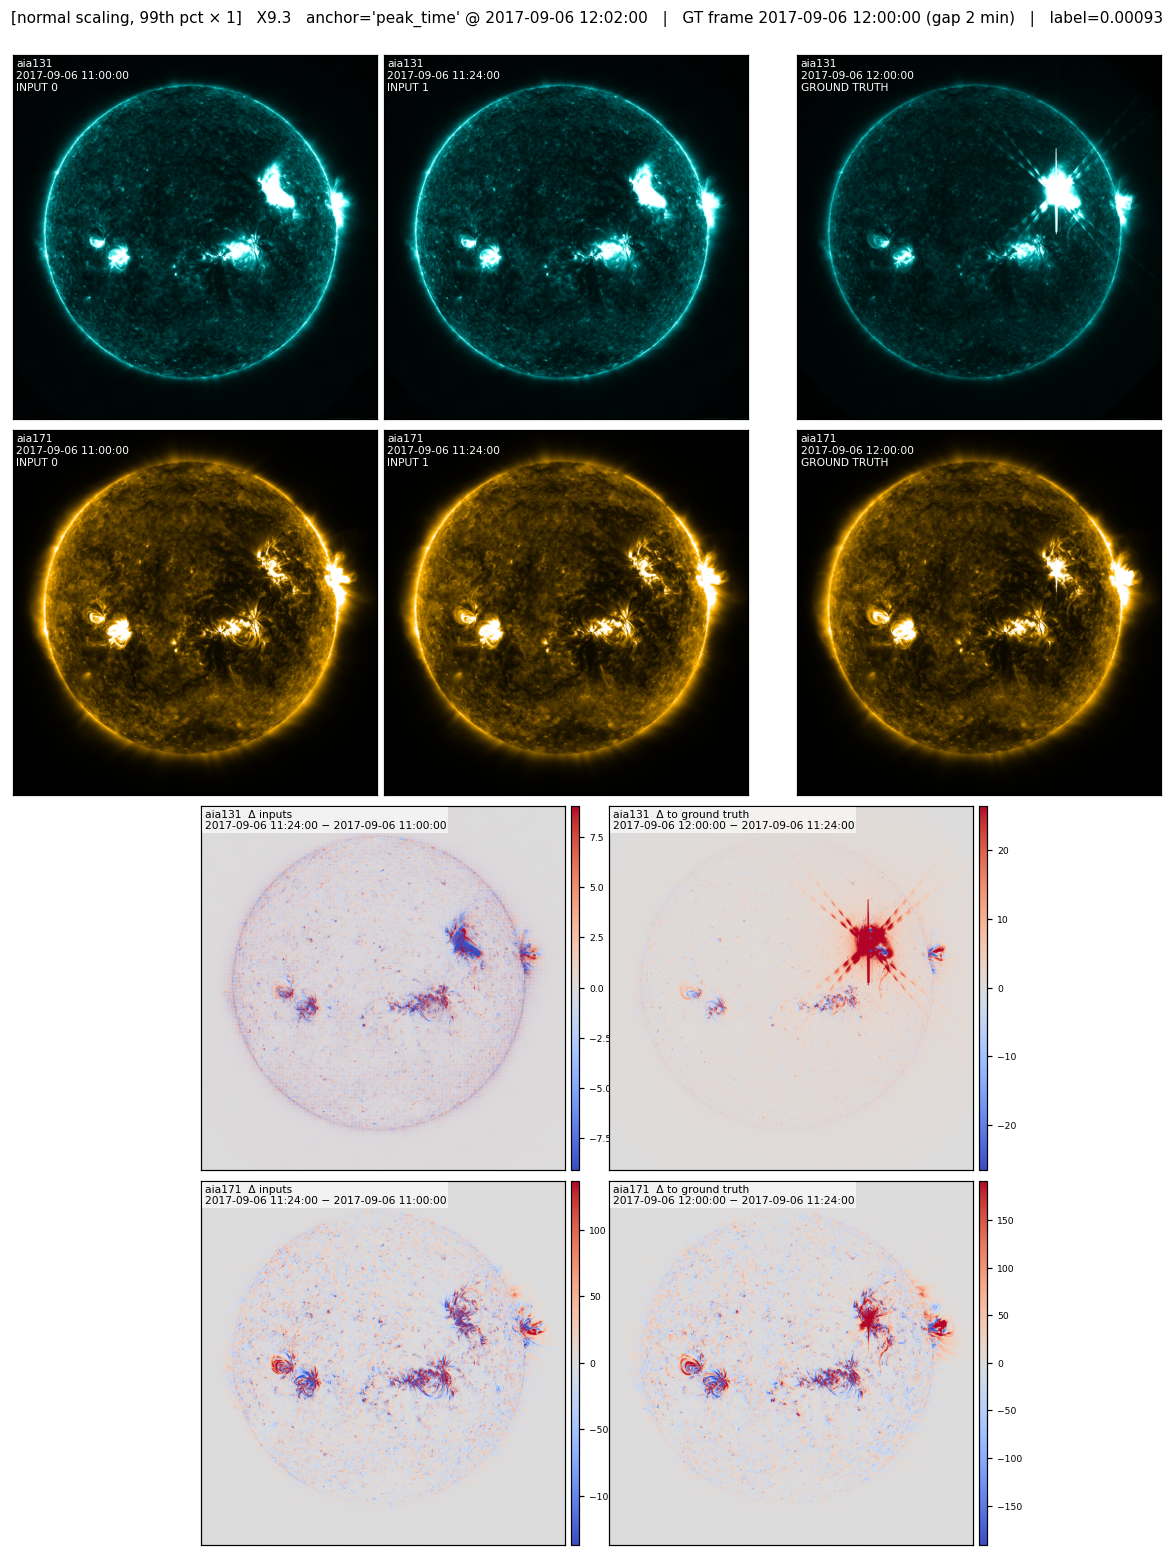

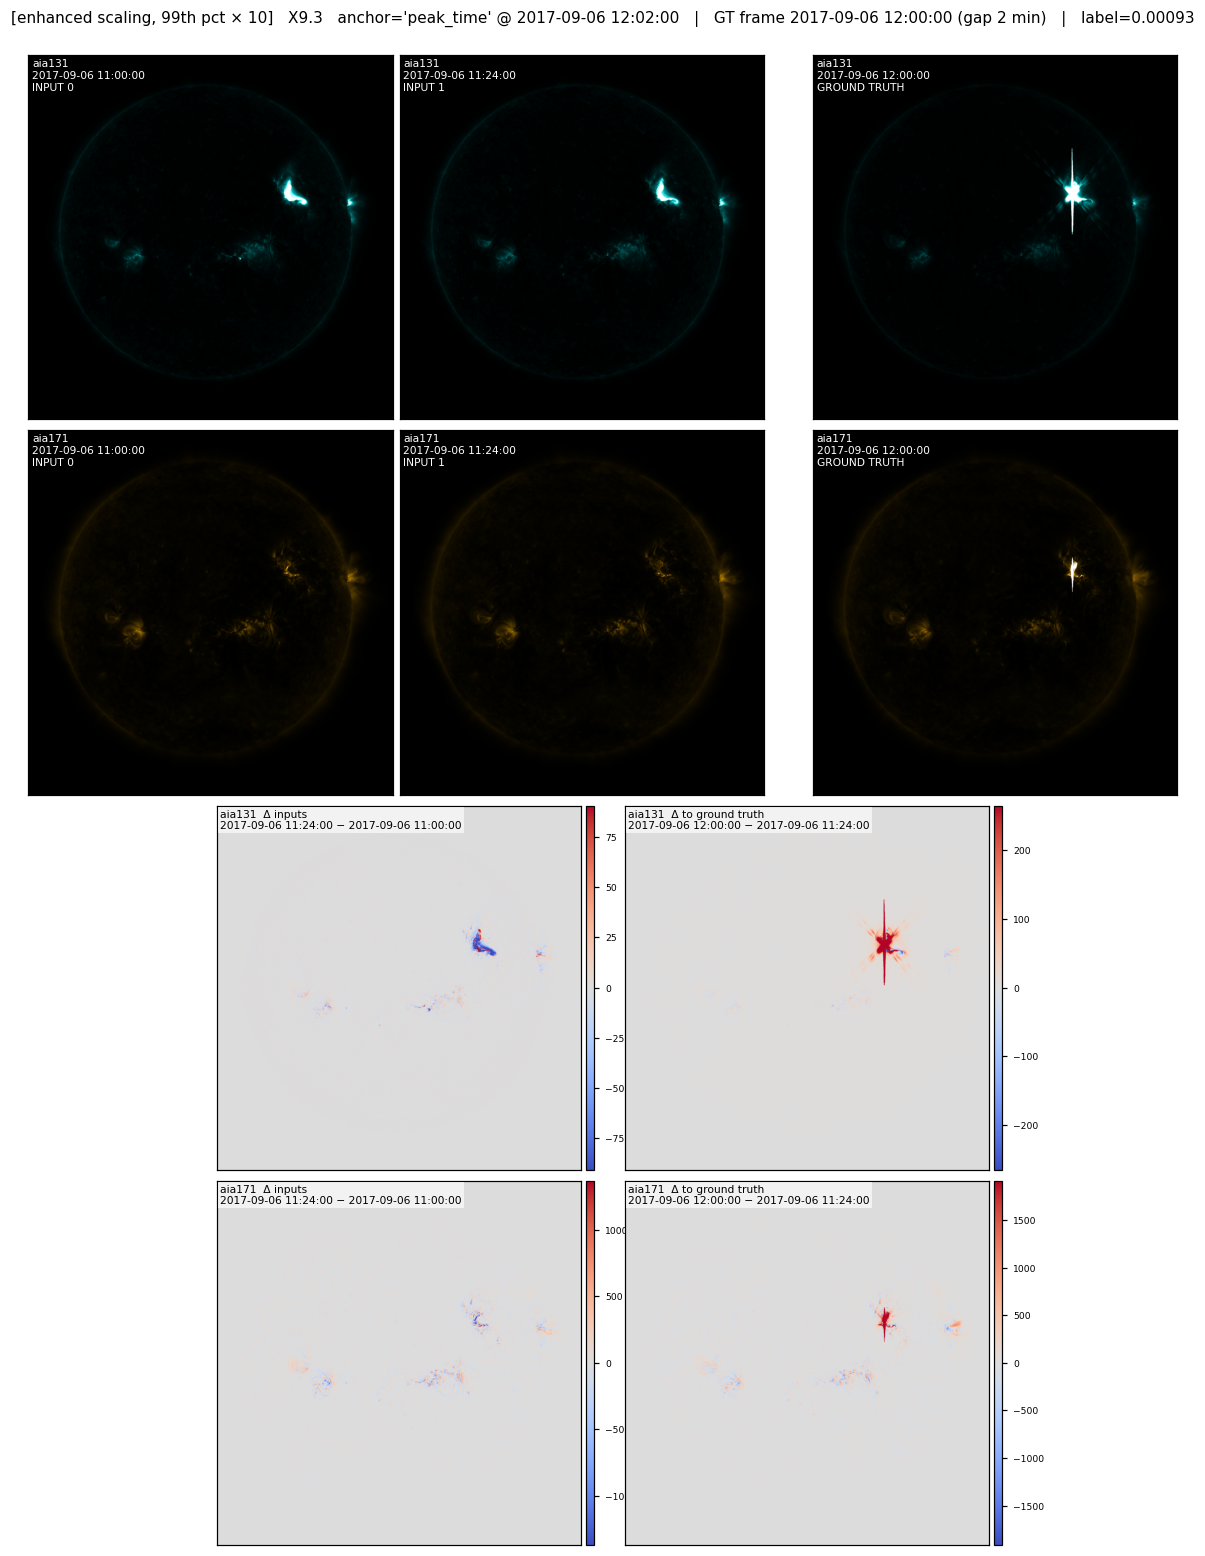

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import sunpy.visualization.colormaps as cm  # registers 'sdoaia131', 'hmimag', ...

# ==================================================================
# CONFIG FOR THIS CHECK
# ==================================================================
CHANNELS_TO_PLOT = ["aia131", "aia171"]          # one row per channel
SCALE_VERSIONS   = [("normal", 1), ("enhanced", 10)]   # 99th-pct multiplier

channel_order = cfg.data.channels
ch_idx = {c: channel_order.index(c) for c in CHANNELS_TO_PLOT}

n_inputs = item["ts"].shape[1]
n_lead   = item["forecast"].shape[1]

# ==================================================================
# 1. TRUE FRAME TIMESTAMPS  (from the sample itself, not from ds_index)
# ==================================================================
reference_timestep = pd.Timestamp(train_dataset.valid_indices[idx])

# helio.py: the LAST entry of the sorted input offsets is the "now" frame.
now_offset_min = sorted(cfg.data.time_delta_input_minutes)[-1]
now_time = reference_timestep + pd.Timedelta(minutes=now_offset_min)

# time_delta_input = hours BEFORE now ; lead_time_delta = hours before now (neg = future)
input_times  = [now_time - pd.Timedelta(minutes=round(float(h) * 60))
                for h in item["time_delta_input"]]
target_times = [now_time - pd.Timedelta(minutes=round(float(h) * 60))
                for h in item["lead_time_delta"]]

# ==================================================================
# 2. PROVENANCE REPORT
# ==================================================================
row = train_dataset.df_valid_indices.iloc[idx]
anchor_col   = cfg.data.ds_time_column
anchor_event = pd.Timestamp(item["ds_index"])
gt_time      = target_times[0]
gap          = abs(gt_time - anchor_event)

print(f"FLARE EVENT      : {row['GOES_class']}   ")
print(f"  start_time     : {row['start_time']}")
print(f"  peak_time      : {row['peak_time']}")
print(f"  end_time       : {row['end_time']}")
print(' ')
print(' ')
print(f"ds_time_column = '{anchor_col}'  ->  {anchor_event}")
print(' ')
print(f"Ground Truth {gt_time}")
print(f"Reference Timestamp (helio.py anchor): {reference_timestep}")
print(f"    offset from {anchor_col:<11}: {gap}  "
      f"({gap.total_seconds()/60:.0f} min)")
print(f"    ds_index vs reference gap: {abs(reference_timestep - anchor_event)}")
print(' ')
print(' ')
print("config: ", cfg.data.time_delta_input_minutes,
      f"  | n_input_timestamps = {train_dataset.n_input_timestamps}")
print(' ')
print("source files:")
for k, ts in enumerate(input_times):
    print(f"  [input {k}] {ts}  (t{'' if k==0 else ''}={(ts-now_time).total_seconds()/60:+.0f} min from now)"
          f"\n            -> {train_dataset.index.loc[ts, 'path']}")
for k, ts in enumerate(target_times):
    print(f"  [GT    {k}] {ts}  ({(ts-now_time).total_seconds()/60:+.0f} min from now)"
          f"\n            -> {train_dataset.index.loc[ts, 'path']}")
print(' ')
print(f"Flipped?  ->  flare_dataset = {item.get('was_flipped')} "
      f"| helio = {getattr(train_dataset, 'random_vert_flip', None)}")
print(' ')
print(' ')
# ==================================================================
# 3. PHYSICAL-UNIT FRAMES PER CHANNEL
# ==================================================================
frames = {}
for c, n in ch_idx.items():
    ins  = [train_dataset.inverse_transform_data(item["ts"][:, t, ...])[n]
            for t in range(n_inputs)]
    tgts = [train_dataset.inverse_transform_data(item["forecast"][:, l, ...])[n]
            for l in range(n_lead)]
    frames[c] = (ins, tgts)
# ==================================================================
# 4. PLOTTING
# ==================================================================
def _lim(a, factor):
    nz = a[a != 0]
    return (np.percentile(nz, 99) * factor) if nz.size else 1.0

def _show(ax, img, channel, label, factor):
    lim = _lim(img, factor)
    if "hmi" not in channel:
        ax.imshow(img, cmap=f"sdo{channel}", vmin=0, vmax=lim)
        fc = "w"
    else:
        fc = "k"
        ax.imshow(img, cmap="coolwarm" if "_v" in channel else "hmimag",
                  vmin=-lim, vmax=lim)
    ax.text(0.01, 0.99, label, transform=ax.transAxes, ha="left", va="top",
            color=fc, fontsize=7)
    ax.set_xticks([]); ax.set_yticks([])

n_cols  = n_inputs + 1 + n_lead                       # +1 = spacer column
w_ratios = [1] * n_inputs + [0.10] + [1] * n_lead

for tag, factor in SCALE_VERSIONS:
    n_rows = len(CHANNELS_TO_PLOT) * 2                # image rows + diff rows
    panel = 3.4                                    # inches per (square) panel
    title_in = 0.42                                # inches reserved for suptitle
    fig_w = panel * (n_inputs + n_lead) + panel * w_ratios[n_inputs]
    fig_h = panel * n_rows + title_in
    fig = plt.figure(figsize=(fig_w, fig_h), dpi=110)
    gs = gridspec.GridSpec(n_rows, n_cols, figure=fig,
                           width_ratios=w_ratios,
                           wspace=0.02, hspace=0.03,
                           left=0.004, right=0.996,
                           top=1 - title_in / fig_h,   # <- kills the title gap
                           bottom=0.004)
    # ---- image rows: one per channel, columns = time ----
    for r, c in enumerate(CHANNELS_TO_PLOT):
        ins, tgts = frames[c]
        for t in range(n_inputs):
            _show(fig.add_subplot(gs[r, t]), ins[t], c,
                  f"{c}\n{input_times[t]}\nINPUT {t}", factor)
        for l in range(n_lead):
            _show(fig.add_subplot(gs[r, n_inputs + 1 + l]), tgts[l], c,
                  f"{c}\n{target_times[l]}\nGROUND TRUTH", factor)
    # ---- diff rows: centered below, layout of grid above untouched ----
    for r, c in enumerate(CHANNELS_TO_PLOT):
        ins, tgts = frames[c]
        diffs = []
        if n_inputs >= 2:
            diffs.append((ins[-1] - ins[-2],
                          f"{c}  Δ inputs\n{input_times[-1]} − {input_times[-2]}"))
        diffs.append((tgts[0] - ins[-1],
                      f"{c}  Δ to ground truth\n{target_times[0]} − {input_times[-1]}"))
        gap_u = w_ratios[n_inputs]
        side  = (sum(w_ratios) - (2 + gap_u)) / 2
        inner = gs[len(CHANNELS_TO_PLOT) + r, :].subgridspec(
            1, 5, width_ratios=[side, 1, gap_u, 1, side], wspace=0)
        for k, (d, title) in enumerate(diffs):
            ax = fig.add_subplot(inner[0, 2 * k + 1])
            lim = np.percentile(np.abs(d), 99) * factor or 1.0
            im = ax.imshow(d, cmap="coolwarm", vmin=-lim, vmax=lim)
            ax.text(0.01, 0.99, title, transform=ax.transAxes, ha="left", va="top",
                    fontsize=7, color="k",
                    bbox=dict(fc="w", ec="none", alpha=0.65, pad=1.5))
            ax.set_xticks([]); ax.set_yticks([])
            cax = ax.inset_axes([1.015, 0.0, 0.022, 1.0])
            cb = fig.colorbar(im, cax=cax)
            cb.ax.tick_params(labelsize=6)
    fig.suptitle(
        f"[{tag} scaling, 99th pct × {factor}]   {row['GOES_class']}   "
        f"anchor='{anchor_col}' @ {anchor_event}   |   GT frame {gt_time} "
        f"(gap {gap.total_seconds()/60:.0f} min)   |   label={float(item['ground_truth']):.4g}",
        fontsize=10, y=0.999)
    plt.show()